In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *

In [29]:
wd = 0.642570281124498
wm = 0.642570281124498
tlist = np.linspace(0, 200, 400)
detuning = 0.5
dlist = np.linspace(0, 4, 41)
N = 4
reals = 50

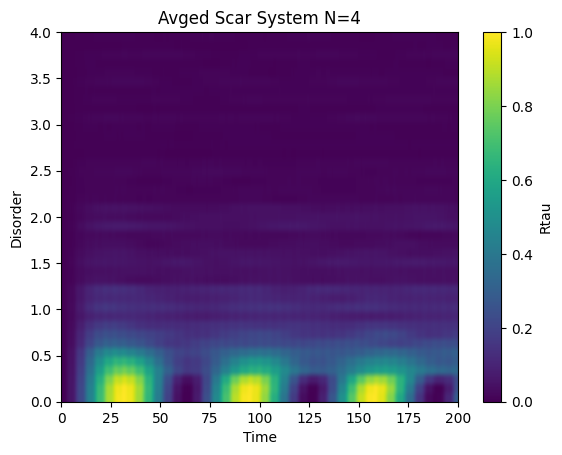

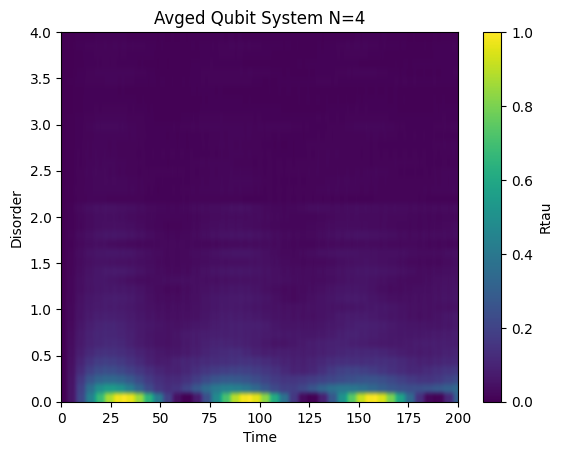

In [30]:
densityRtau_scar = []
for d in dlist:
    zeroes = np.zeros(len(tlist))
    for _ in range(reals):
        H0, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N, disorder=True, detuning=d, random_seed=True)
        args = {"A": 0.1, "omega": wd}
        H = qt.QobjEvo([H0, [H1, coeff]], args=args)
        psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
        Rtau = np.real(psi_t.expect[0] - psi_t.expect[0][0]) / (eigenvalues[-1] - eigenvalues[0])
        zeroes += Rtau
    densityRtau_scar.append(zeroes / reals)

plt.imshow(densityRtau_scar,
           extent=[tlist.min(), tlist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label="Rtau")
plt.title(f"Avged Scar System N={N}")
plt.ylabel("Disorder")
plt.xlabel("Time")
plt.show()

# decoupled system
densityRtau_qubit = []
for d in dlist:
    zeroes = np.zeros(len(tlist))
    for _ in range(reals):
        qH0, qH1 = get_qubit_ham(N, wm=wm, disorder=True, detuning=d, random_seed=True)
        qeigvals, qeigstates = qH0.eigenstates()
        qband = qeigvals[-1] - qeigvals[0]

        qargs = {"A": 0.1, "omega": wm}
        qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
        qpsi_t = qt.sesolve(qH, qeigstates[0], tlist, e_ops=[qH0])
        qRtau = np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0]) / qband
        zeroes += qRtau
    densityRtau_qubit.append(zeroes / reals)

plt.imshow(densityRtau_qubit,
           extent=[tlist.min(), tlist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label="Rtau")
plt.title(f"Avged Qubit System N={N}")
plt.ylabel("Disorder")
plt.xlabel("Time")
plt.show()

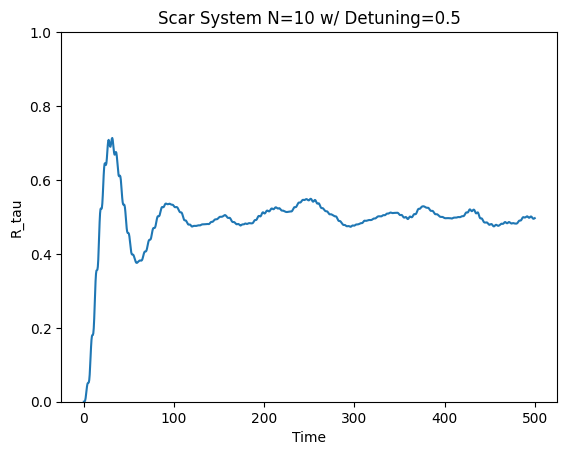

In [12]:
# scar system
args = {"A": 0.1, "omega": wd}
H0, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N, disorder=True, detuning=detuning)
H = qt.QobjEvo([H0, [H1, coeff]], args=args)
psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
Rtau = np.real(psi_t.expect[0] - psi_t.expect[0][0]) / (eigenvalues[-1] - eigenvalues[0])

# eq 4.1
plt.title(f"Scar System N={N} w/ Detuning={detuning}")
plt.ylabel("R_tau")
plt.xlabel("Time")
plt.ylim(0, 1)
plt.plot(tlist, Rtau)
plt.show()

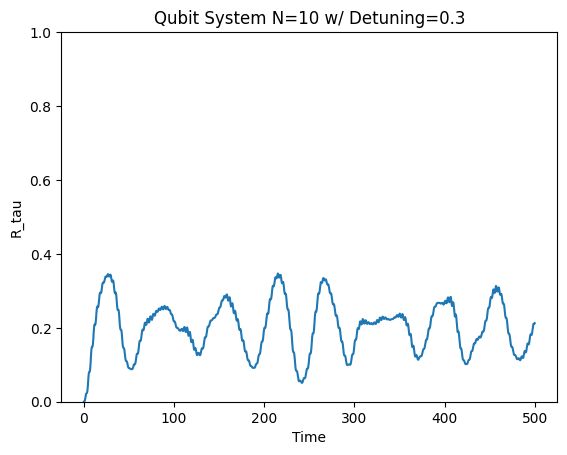

In [10]:
# non interacting qubit
qH0, qH1, wm = get_qubit_ham(N, wm=1.0, disorder=True, detuning=detuning)
qargs = {"A": 0.1, "omega": wm}
qpsi0 = qt.tensor([qt.basis(2,0)]*N)
qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
qpsi_t = qt.sesolve(qH, qpsi0, tlist, e_ops=[qH0])

# bandwidth
qevals, qestates = qH0.eigenstates()
qband = qevals[-1] - qevals[0]

qRtau = np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0]) / qband

# eq 4.1
plt.title(f"Qubit System N={N} w/ Detuning={detuning}")
plt.ylabel("R_tau")
plt.xlabel("Time")
plt.ylim(0, 1)
plt.plot(tlist, qRtau)
plt.show()

In [21]:
# eq 2.5
expectationEbar = []
for states in psi_t.states:
    expectationEbar.append(states.dag() * H0 * states)
integral = np.trapezoid(tlist, expectationEbar)
E_bar = integral / tau

In [22]:
# ergotropy calculation
def trace(mat):
    basisLen = len(basisList)
    toBeSummed = [qt.basis(basisLen, i).dag() * mat * qt.basis(basisLen, i) for i in range(basisLen)]
    return sum(toBeSummed)

ergoList = []
passiveErgo = trace(psi0 * psi0.dag() * H0)
for states in psi_t.states:
    densityMat = states * states.dag()
    innerTrace = densityMat * H0
    ergoList.append(trace(innerTrace) - passiveErgo)

plt.plot(tlist, ergoList)
plt.ylabel("Ergotropy")
plt.xlabel("Time")
plt.show()

KeyboardInterrupt: 